# **TASK - 1**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
file_path = "/content/drive/MyDrive/train.csv"

In [6]:
df = pd.read_csv(file_path)

In [7]:
print("Dataset Loaded Successfully!")

print("Shape of Dataset:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape of Dataset: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [10]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [12]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y'
)

In [16]:
# Extract time-based features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Week Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Function to assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Display the new columns
df[['Order Date', 'Year', 'Month', 'Week Number', 'Day of Week', 'Quarter', 'Season']].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


In [17]:
print("Missing Values:\n")

df.isnull().sum()

Missing Values:



,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [23]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])

In [24]:
#Rechecking the values
print("Missing Values:\n")

df.isnull().sum()

Missing Values:



,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [18]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [19]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [20]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [21]:
weekly_sales = (
    df
    .resample('W', on='Order Date')['Sales']
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [22]:
monthly_sales = (
    df
    .resample('M', on='Order Date')['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


**Business Question 1**

Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


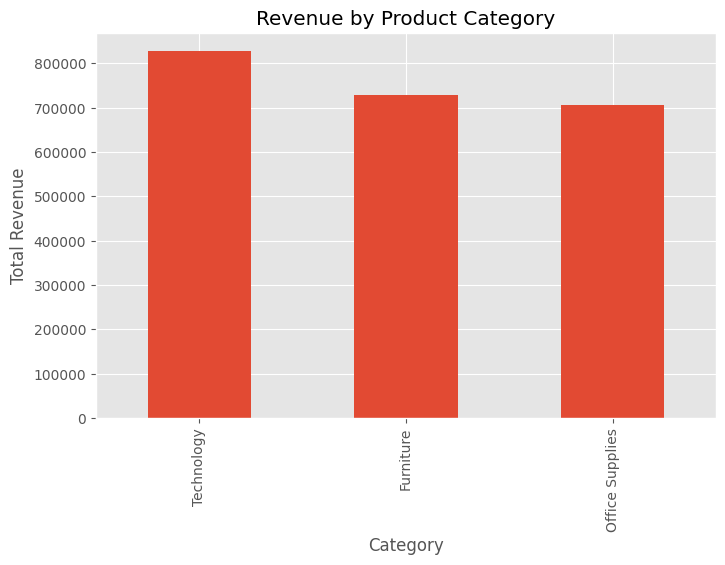

In [25]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Revenue by Product Category")

plt.xlabel("Category")

plt.ylabel("Total Revenue")

plt.show()

**Business Question 2**

Which region has the most consistent sales growth over 4 years?

In [26]:
region_year_sales = (
    df.groupby(['Region','Year'])['Sales']
      .sum()
      .reset_index()
)

region_year_sales
fig = px.line(
    region_year_sales,
    x='Year',
    y='Sales',
    color='Region',
    markers=True,
    title='Regional Sales Growth Over Time'
)

fig.show()

In [29]:
consistency = (
    region_year_sales
    .groupby('Region')['Sales']
    .std()
    .sort_values()
)

print(consistency)

print("Most Consistent Region:")
print(consistency.idxmin())

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64
Most Consistent Region:
South


**Business Question 3**

Average Shipping Time

Average Shipping Time:
3.9611224489795918
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


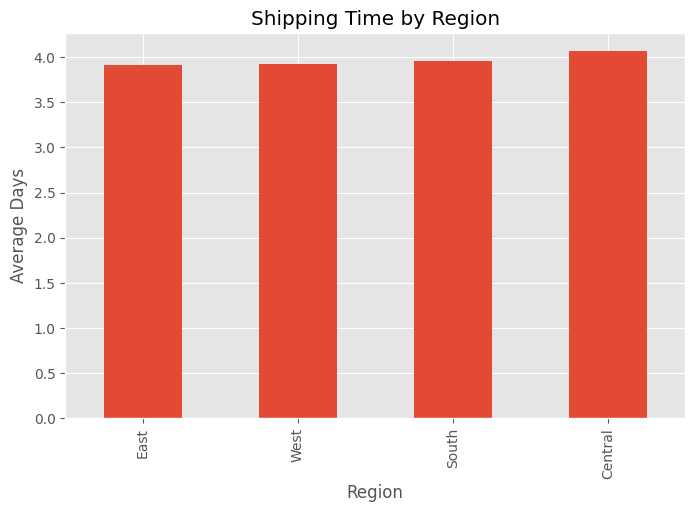

In [30]:
df['Shipping Days'] = (
    df['Ship Date'] -
    df['Order Date']
).dt.days

#overall
print("Average Shipping Time:")

print(df['Shipping Days'].mean())

#region-wise
shipping_region = (
    df.groupby('Region')['Shipping Days']
      .mean()
      .sort_values()
)

print(shipping_region)

plt.figure(figsize=(8,5))

shipping_region.plot(kind='bar')

plt.ylabel("Average Days")

plt.title("Shipping Time by Region")

plt.show()

**Business Question 4**

Do months consistently spike across all years?

In [31]:
monthly = (
    df.groupby(['Year','Month Name','Month'])['Sales']
      .sum()
      .reset_index()
)

monthly
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly['Month Name'] = pd.Categorical(
    monthly['Month Name'],
    categories=month_order,
    ordered=True
)

monthly = monthly.sort_values(['Year','Month'])
fig = px.line(
    monthly,
    x='Month Name',
    y='Sales',
    color='Year',
    markers=True,
    title='Monthly Sales Across Years'
)

fig.show()

In [36]:
print("Summary")
print("Dataset Shape :", df.shape)
print("Missing Values :", df.isnull().sum().sum())
print("Duplicate Rows :", df.duplicated().sum())
print("Highest Revenue Category :", category_sales.idxmax())
print("Most Consistent Region :", consistency.idxmin())
print("Average Shipping Days :", round(df['Shipping Days'].mean(),2))

Summary
Dataset Shape : (9800, 26)
Missing Values : 0
Duplicate Rows : 0
Highest Revenue Category : Technology
Most Consistent Region : South
Average Shipping Days : 3.96


## **TASK - 2**

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
import pandas as pd

In [38]:
monthly_sales = (
    df.groupby('Order Date')['Sales']
      .sum()
      .resample('M')
      .sum()
)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


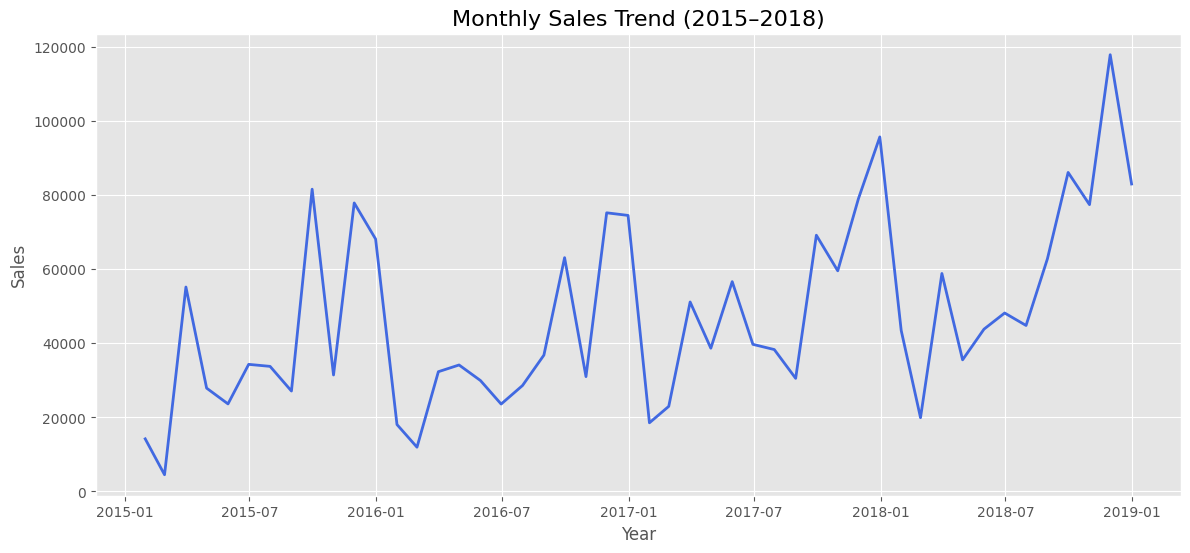

In [39]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales, color='royalblue', linewidth=2)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [40]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

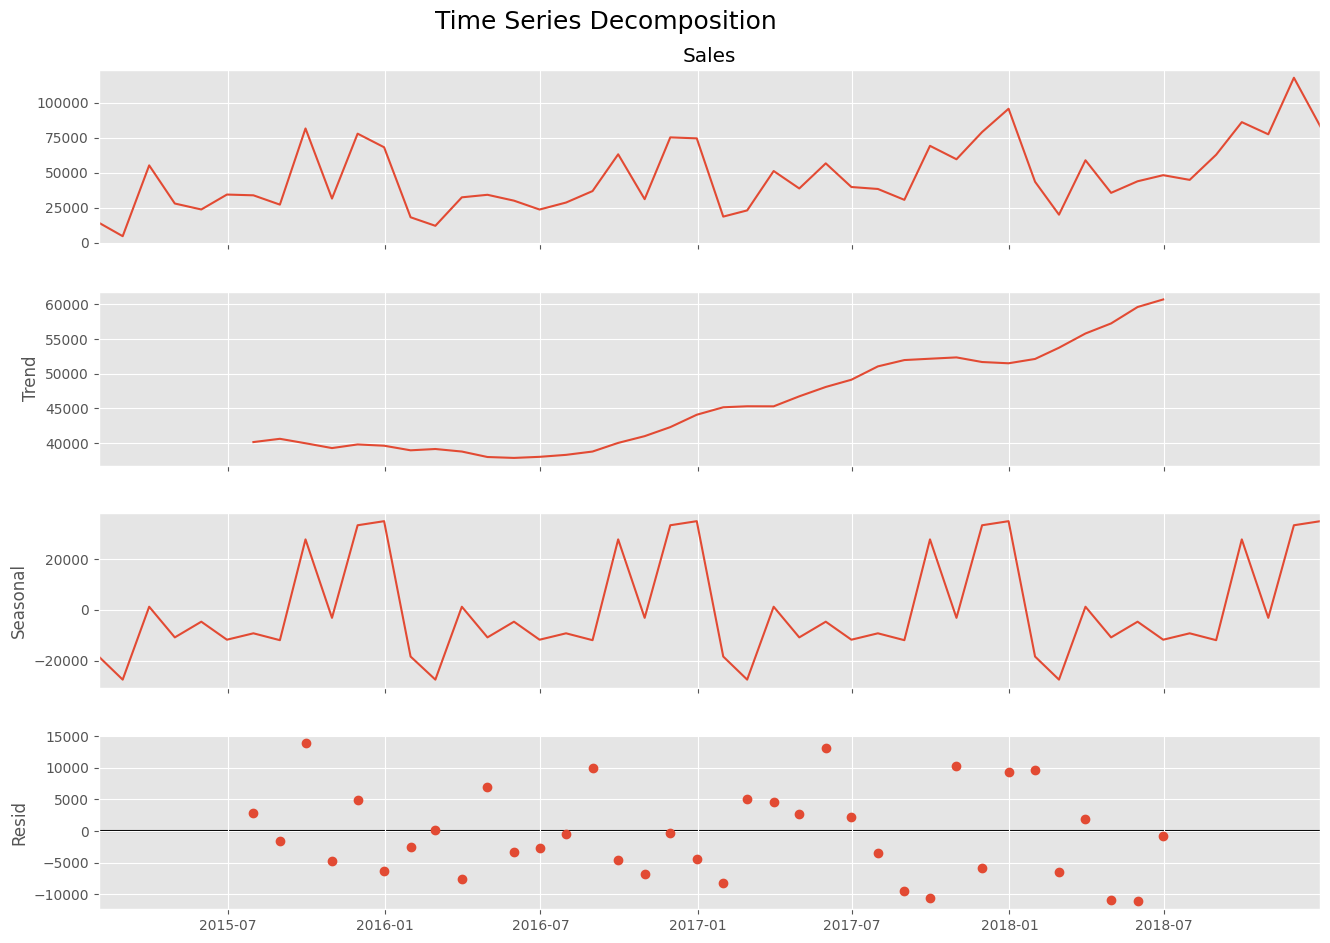

In [41]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.suptitle("Time Series Decomposition", fontsize=18)

plt.show()

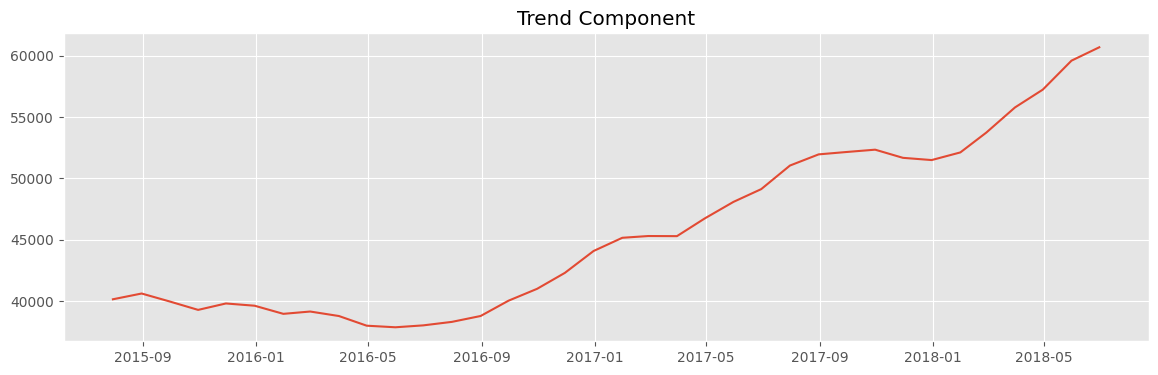

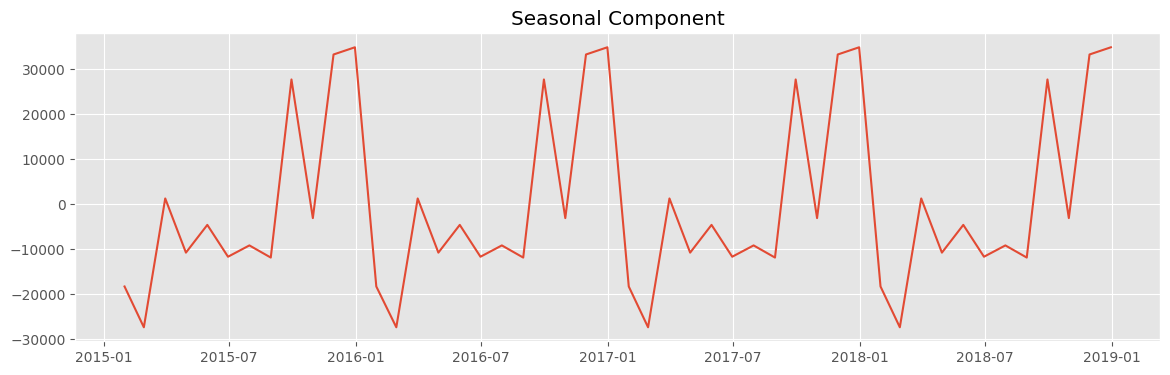

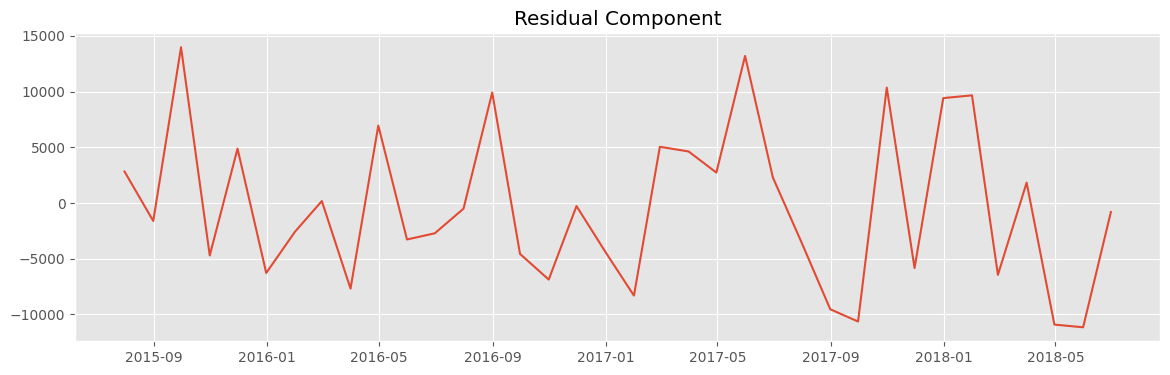

In [42]:
#trend
plt.figure(figsize=(14,4))
plt.plot(decomposition.trend)
plt.title("Trend Component")
plt.grid(True)
plt.show()

#seasonlity
plt.figure(figsize=(14,4))
plt.plot(decomposition.seasonal)
plt.title("Seasonal Component")
plt.grid(True)
plt.show()

#residual
plt.figure(figsize=(14,4))
plt.plot(decomposition.resid)
plt.title("Residual Component")
plt.grid(True)
plt.show()

In [43]:
result = adfuller(monthly_sales.dropna())

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values:
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [44]:
if result[1] < 0.05:
    print("The time series is stationary.")
else:
    print("The time series is non-stationary.")

The time series is stationary.


In [45]:
print("Monthly Sales Summary:")
monthly_sales.describe()

Monthly Sales Summary:


,Sales
count,48.000000
mean,47115.349640
std,24978.687305
min,4519.892000
25%,29621.712625
50%,39202.126500
75%,64391.969125
max,117938.155000


In [47]:
print("TIME SERIES ANALYSIS SUMMARY")

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.4f}")

if result[1] < 0.05:
    print("\nResult:")
    print("The monthly sales series is stationary.")
    print("No differencing is required.")
    print("The data can be used directly for forecasting models.")
else:
    print("\nResult:")
    print("The monthly sales series is non-stationary.")
    print("Differencing is required before forecasting.")

TIME SERIES ANALYSIS SUMMARY
ADF Statistic : -4.4161
P-value       : 0.0003

Result:
The monthly sales series is stationary.
No differencing is required.
The data can be used directly for forecasting models.


# Observations
1.The monthly sales trend shows an overall increasing pattern across the four-year period, indicating business growth.

2.The seasonal component exhibits recurring patterns across months, suggesting that sales are influenced by seasonal demand.

3.The residual component contains random fluctuations that are not explained by the trend or seasonal effects. Some months show larger deviations, which may indicate promotions or unusual events.

4.The Augmented Dickey-Fuller (ADF) test produced a p-value less than 0.05, indicating that the time series is stationary. Therefore, no differencing was required, and the series can be used directly for forecasting.




# **TASK - 3**

Model 1: SARIMA Forecasting

In [48]:
# Install statsmodels
!pip install statsmodels -q

In [49]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [50]:
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [51]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

Training Months : 45
Testing Months : 3


In [61]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings

warnings.filterwarnings("ignore")

p = q = range(0, 3)
d = [0]  # Your series is already stationary

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], 0, x[2], 12) for x in itertools.product(range(0,2), range(0,2), range(0,2))]

best_aic = float("inf")
best_order = None
best_seasonal = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order
                best_seasonal = seasonal_order

        except:
            continue

print("Best AIC:", best_aic)
print("Best Order:", best_order)
print("Best Seasonal:", best_seasonal)

Best AIC: 698.3029133395255
Best Order: (2, 0, 1)
Best Seasonal: (1, 0, 0, 12)


In [62]:
sarima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   45
Model:             SARIMAX(2, 0, 1)x(1, 0, [], 12)   Log Likelihood                -344.151
Date:                             Mon, 13 Jul 2026   AIC                            698.303
Time:                                     13:01:54   BIC                            705.473
Sample:                                 01-31-2015   HQIC                           700.640
                                      - 09-30-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2605      0.964      1.307      0.191      -0.629       3.150
ar.L2         -0.2587      

In [70]:
forecast = sarima_fit.get_forecast(steps=3)
confidence_interval = forecast.conf_int()

print(confidence_interval)

forecast_mean = forecast.predicted_mean


             lower Sales    upper Sales
2018-10-31  21587.455604  111894.867545
2018-11-30  29663.927516  123270.628455
2018-12-31  39849.634791  133768.795302


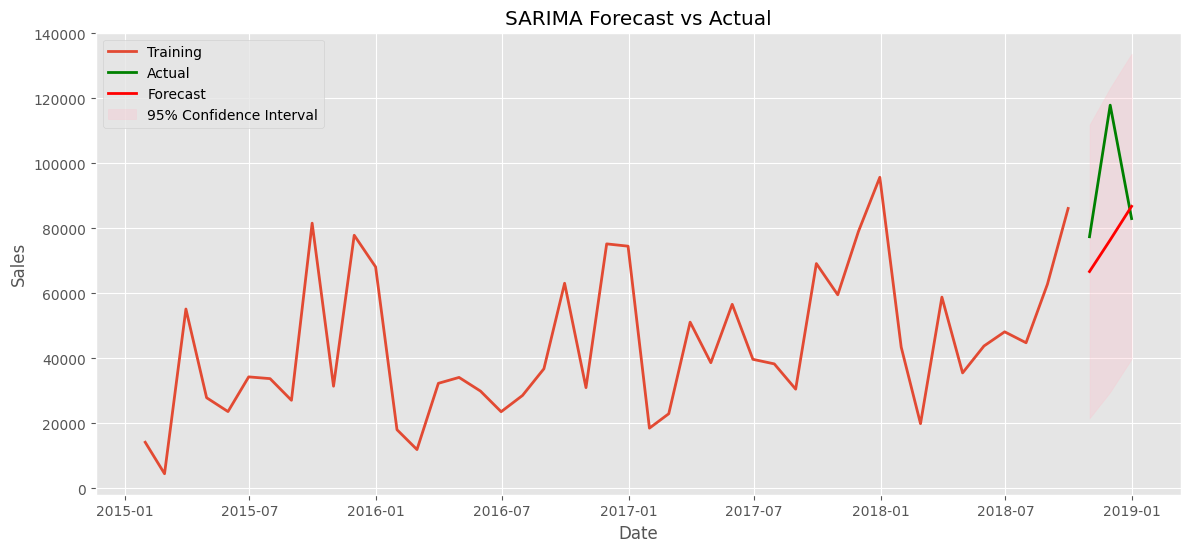

In [71]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Training', linewidth=2)
plt.plot(test.index, test, label='Actual', color='green', linewidth=2)
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red', linewidth=2)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
mae_sarima = mean_absolute_error(
    test,
    forecast_mean
)

print("MAE :", mae_sarima)

MAE : 18652.224295329


In [67]:
rmse_sarima = np.sqrt(
    mean_squared_error(
        test,
        forecast_mean
    )
)

print("RMSE :", rmse_sarima)

RMSE : 24824.399064136607


In [68]:
mape_sarima = np.mean(
    np.abs(
        (test - forecast_mean) / test
    )
) * 100

print("MAPE :", mape_sarima)

MAPE : 17.84635801306909


In [69]:
print("Forecast for Next 3 Months")

forecast_mean

Forecast for Next 3 Months


,predicted_mean
2018-10-31,66741.161574
2018-11-30,76467.277986
2018-12-31,86809.215046


Several SARIMA parameter combinations were evaluated using the Akaike Information Criterion (AIC). The model with the lowest AIC was selected because it provided the best balance between model fit and complexity. Since the ADF test confirmed that the time series was stationary, differencing parameters d=0 and D=0 were used. A seasonal period of 12 months was chosen to capture yearly seasonality in the monthly sales data.

Model 2: Facebook Prophet.

In [72]:
!pip install prophet -q

In [73]:
from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

In [74]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [75]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [76]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [77]:
model.fit(train_prophet)

In [78]:
future = model.make_future_dataframe(
    periods=3,
    freq='M'
)

future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [79]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277791,38516.394175,55376.565929,54942.277791,54942.277791,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557312
44,2018-09-30,55441.608183,77834.338780,93483.214148,55441.608183,55441.608183,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953555
45,2018-10-31,55957.582922,43897.815094,59578.699198,55957.427583,55957.737222,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944572
46,2018-11-30,56456.913314,81948.426882,98632.519391,56456.402362,56457.448496,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653854
47,2018-12-31,56972.888053,81619.996890,98126.398710,56971.856820,56973.957148,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084638


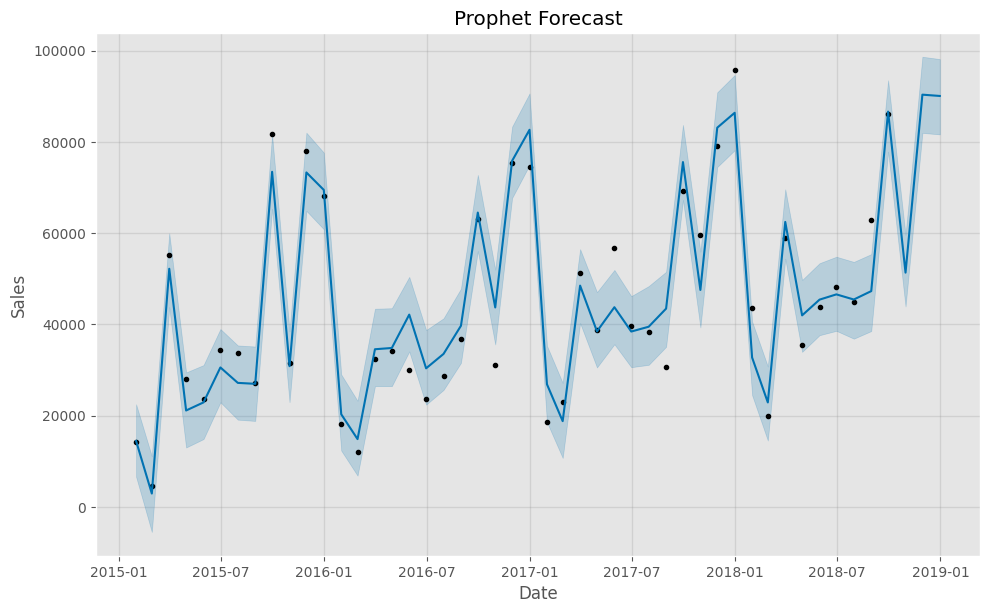

In [80]:
fig = model.plot(forecast)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

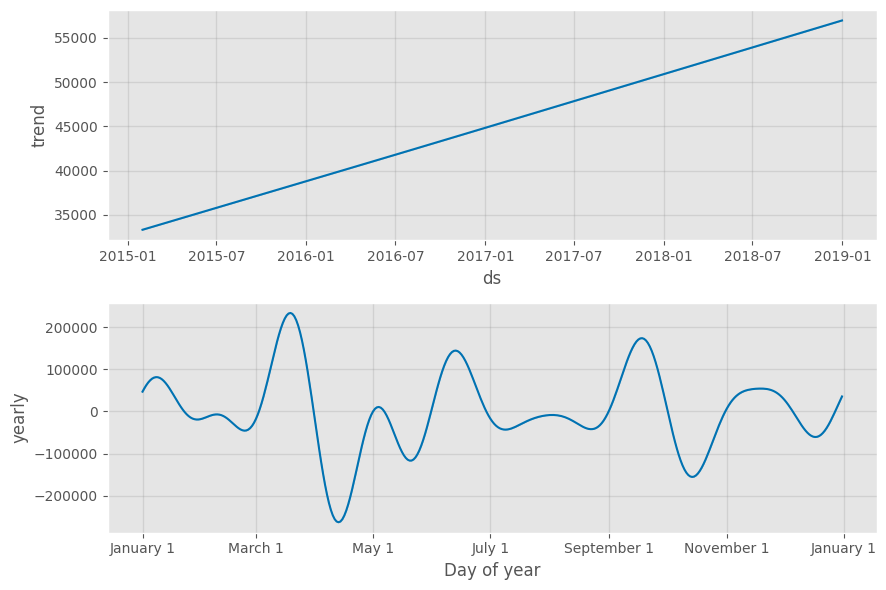

In [81]:
model.plot_components(forecast)

plt.show()

# **Trend**
The trend plot shows the long-term direction of sales over time. An upward trend indicates increasing business growth, while a downward trend would suggest declining sales.

# **Yearly Seasonality**
The yearly seasonality plot highlights recurring monthly patterns. Positive peaks represent months with above-average sales, while negative values indicate relatively weaker sales months.

# **Weekly Seasonality**
Weekly seasonality was not modeled because the data was aggregated to monthly sales. Only yearly seasonality was included, as it is meaningful at the monthly granularity.

In [82]:
forecast_test = forecast[['ds','yhat']].tail(3)

forecast_test

,ds,yhat
45,2018-10-31,51318.944572
46,2018-11-30,90325.653854
47,2018-12-31,90041.084638


In [83]:
comparison = pd.DataFrame({
    'Date': test_prophet['ds'].values,
    'Actual': test_prophet['y'].values,
    'Forecast': forecast_test['yhat'].values
})

comparison

,Date,Actual,Forecast
0,2018-10-31,77448.1312,51318.944572
1,2018-11-30,117938.1550,90325.653854
2,2018-12-31,83030.3888,90041.084638


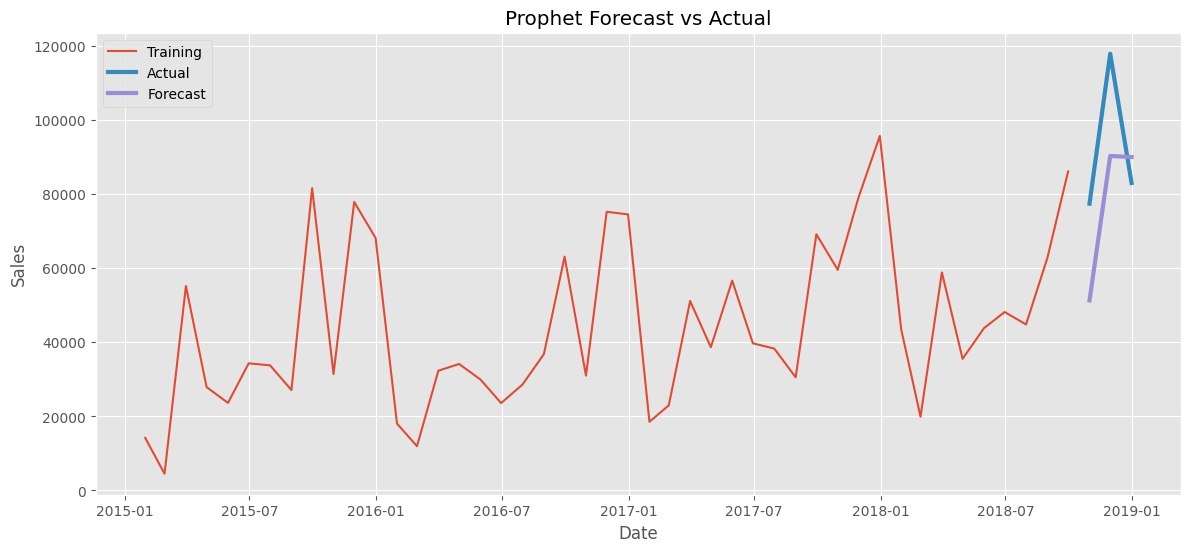

In [84]:
plt.figure(figsize=(14,6))

plt.plot(
    train_prophet['ds'],
    train_prophet['y'],
    label='Training'
)

plt.plot(
    test_prophet['ds'],
    test_prophet['y'],
    label='Actual',
    linewidth=3
)

plt.plot(
    forecast_test['ds'],
    forecast_test['yhat'],
    label='Forecast',
    linewidth=3
)

plt.title("Prophet Forecast vs Actual")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [85]:
mae_prophet = mean_absolute_error(
    test_prophet['y'],
    forecast_test['yhat']
)

print("MAE :", mae_prophet)

MAE : 20250.794537282793


In [86]:
rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        forecast_test['yhat']
    )
)

print("RMSE :", rmse_prophet)

RMSE : 22318.411454222576


In [87]:
mape_prophet = np.mean(
    np.abs(
        (
            test_prophet['y'] -
            forecast_test['yhat']
        )
        /
        test_prophet['y']
    )
) * 100

print("MAPE :", mape_prophet)

MAPE : 21.864628292994944


In [88]:
print("Forecast for Next 3 Months")

forecast_test

Forecast for Next 3 Months


,ds,yhat
45,2018-10-31,51318.944572
46,2018-11-30,90325.653854
47,2018-12-31,90041.084638


Model 3: XGBoost for Time Series

In [89]:
!pip install xgboost -q

In [90]:
import pandas as pd
import numpy as np

import xgboost as xgb

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [91]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ['Date','Sales']

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [92]:
xgb_df['Lag_1'] = xgb_df['Sales'].shift(1)

In [93]:
xgb_df['Lag_2'] = xgb_df['Sales'].shift(2)

In [94]:
xgb_df['Lag_3'] = xgb_df['Sales'].shift(3)

In [95]:
xgb_df['Rolling_Mean_3'] = (
    xgb_df['Sales']
    .rolling(3)
    .mean()
)

In [96]:
xgb_df['Month'] = xgb_df['Date'].dt.month

xgb_df['Quarter'] = xgb_df['Date'].dt.quarter

In [97]:
def season(month):

    if month in [12,1,2]:
        return 1

    elif month in [3,4,5]:
        return 2

    elif month in [6,7,8]:
        return 3

    else:
        return 4

xgb_df['Season'] = xgb_df['Month'].apply(season)

In [98]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


In [99]:
features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_Mean_3',
    'Month',
    'Quarter',
    'Season'
]

X = xgb_df[features]

y = xgb_df['Sales']

In [100]:
X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [101]:
model_xgb = xgb.XGBRegressor(

    n_estimators=200,

    learning_rate=0.05,

    max_depth=3,

    random_state=42
)

model_xgb.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [102]:
xgb_pred = model_xgb.predict(X_test)

In [103]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": xgb_pred

})

comparison.index = xgb_df['Date'].tail(3)

comparison

,Actual,Predicted
Date,,
2018-10-31,77448.1312,86530.492188
2018-11-30,117938.1550,87955.140625
2018-12-31,83030.3888,88256.445312


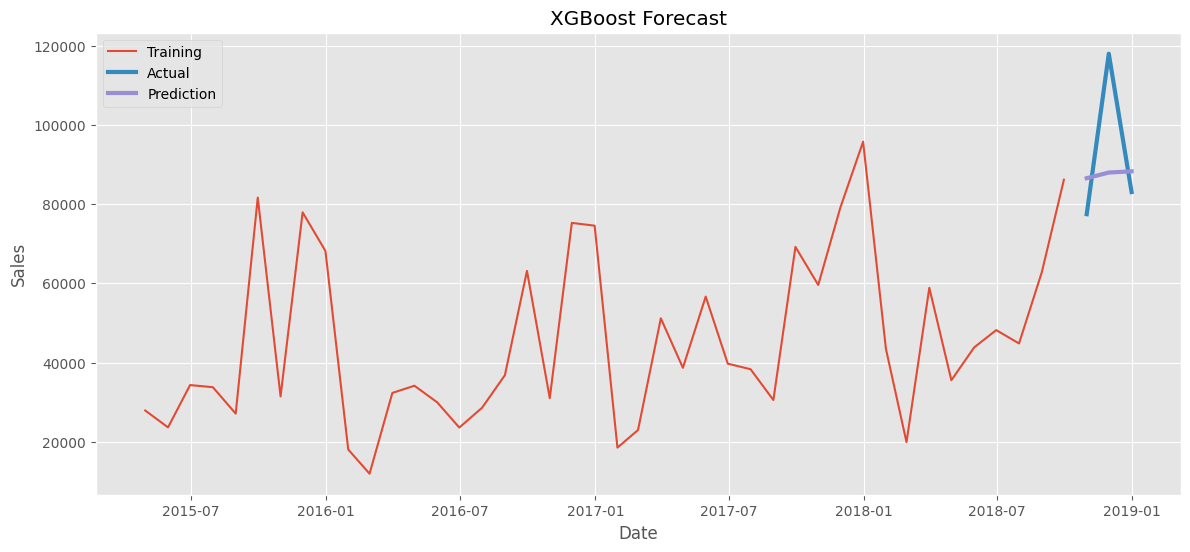

In [104]:
plt.figure(figsize=(14,6))

plt.plot(
    xgb_df['Date'][:-3],
    y_train,
    label='Training'
)

plt.plot(
    xgb_df['Date'].tail(3),
    y_test,
    label='Actual',
    linewidth=3
)

plt.plot(
    xgb_df['Date'].tail(3),
    xgb_pred,
    label='Prediction',
    linewidth=3
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [105]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

print("MAE :", mae_xgb)

MAE : 14763.810624999998


In [106]:
rmse_xgb = np.sqrt(

    mean_squared_error(

        y_test,

        xgb_pred

    )

)

print("RMSE :", rmse_xgb)

RMSE : 18337.412565486276


In [107]:
mape_xgb = np.mean(

    np.abs(

        (y_test-xgb_pred)

        /

        y_test

    )

)*100

print("MAPE :", mape_xgb)

MAPE : 14.481277237255794


In [108]:
forecast_xgb = pd.DataFrame({

    "Month": xgb_df['Date'].tail(3),

    "Forecast": xgb_pred

})

forecast_xgb

,Month,Forecast
45,2018-10-31,86530.492188
46,2018-11-30,87955.140625
47,2018-12-31,88256.445312


In [110]:
future_df = xgb_df.copy()

In [111]:
future_predictions = []

last_date = future_df['Date'].iloc[-1]

for i in range(3):

    lag1 = future_df['Sales'].iloc[-1]
    lag2 = future_df['Sales'].iloc[-2]
    lag3 = future_df['Sales'].iloc[-3]

    rolling_mean = future_df['Sales'].iloc[-3:].mean()

    next_date = last_date + pd.DateOffset(months=1)

    month = next_date.month
    quarter = next_date.quarter

    if month in [12,1,2]:
        season = 1
    elif month in [3,4,5]:
        season = 2
    elif month in [6,7,8]:
        season = 3
    else:
        season = 4

    features = pd.DataFrame({

        'Lag_1':[lag1],
        'Lag_2':[lag2],
        'Lag_3':[lag3],
        'Rolling_Mean_3':[rolling_mean],
        'Month':[month],
        'Quarter':[quarter],
        'Season':[season]

    })

    prediction = model_xgb.predict(features)[0]

    future_predictions.append(prediction)

    new_row = pd.DataFrame({

        'Date':[next_date],
        'Sales':[prediction],
        'Lag_1':[lag1],
        'Lag_2':[lag2],
        'Lag_3':[lag3],
        'Rolling_Mean_3':[rolling_mean],
        'Month':[month],
        'Quarter':[quarter],
        'Season':[season]

    })

    future_df = pd.concat([future_df, new_row], ignore_index=True)

    last_date = next_date

In [112]:
future_forecast = pd.DataFrame({

    "Month":[
        "Month 1",
        "Month 2",
        "Month 3"
    ],

    "Forecast Sales":future_predictions

})

future_forecast

,Month,Forecast Sales
0,Month 1,51760.023438
1,Month 2,31282.179688
2,Month 3,59958.382812


In [113]:
future_dates = pd.date_range(

    start=xgb_df['Date'].max()+pd.DateOffset(months=1),

    periods=3,

    freq='M'

)

future_forecast = pd.DataFrame({

    "Date":future_dates,

    "Forecast Sales":future_predictions

})

future_forecast

,Date,Forecast Sales
0,2019-01-31,51760.023438
1,2019-02-28,31282.179688
2,2019-03-31,59958.382812


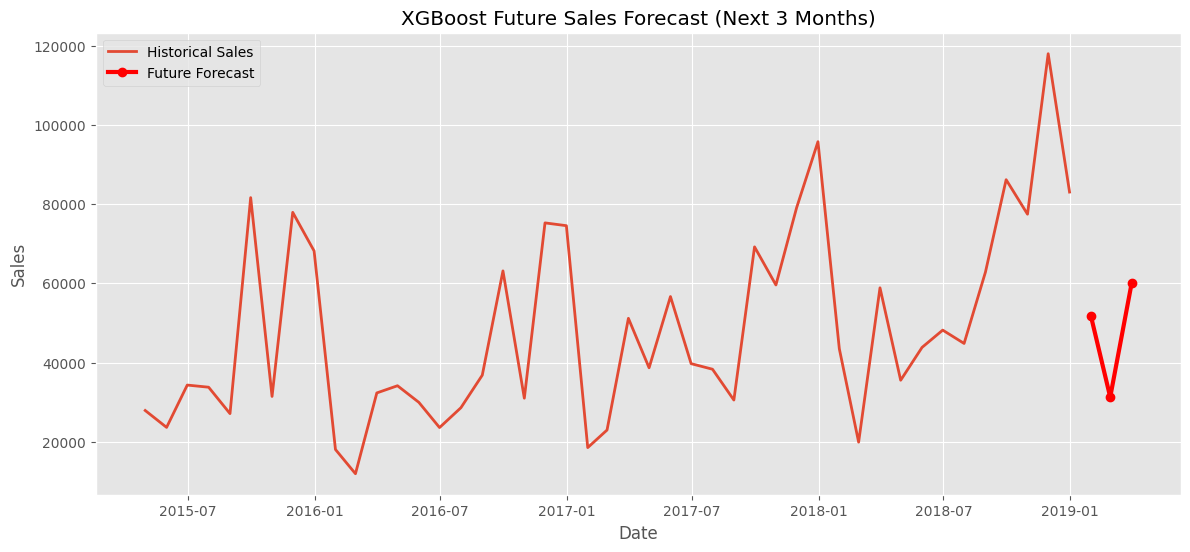

In [114]:
plt.figure(figsize=(14,6))

plt.plot(

    xgb_df['Date'],

    xgb_df['Sales'],

    label='Historical Sales',

    linewidth=2

)

plt.plot(

    future_forecast['Date'],

    future_forecast['Forecast Sales'],

    marker='o',

    linewidth=3,

    color='red',

    label='Future Forecast'

)

plt.title("XGBoost Future Sales Forecast (Next 3 Months)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [115]:
comparison_table = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],

    "RMSE":[
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ],

    "MAPE":[
        mape_sarima,
        mape_prophet,
        mape_xgb
    ],

    "Forecast Month 1":[
        forecast_mean.iloc[0],
        forecast_test['yhat'].iloc[0],
        xgb_pred[0]
    ],

    "Forecast Month 2":[
        forecast_mean.iloc[1],
        forecast_test['yhat'].iloc[1],
        xgb_pred[1]
    ],

    "Forecast Month 3":[
        forecast_mean.iloc[2],
        forecast_test['yhat'].iloc[2],
        xgb_pred[2]
    ]

})

comparison_table

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18652.224295,24824.399064,17.846358,66741.161574,76467.277986,86809.215046
1,Prophet,20250.794537,22318.411454,21.864628,51318.944572,90325.653854,90041.084638
2,XGBoost,14763.810625,18337.412565,14.481277,86530.492188,87955.140625,88256.445312


In [116]:
best_model = comparison_table.loc[comparison_table['MAPE'].idxmin(), 'Model']

print("Recommended Model:", best_model)

Recommended Model: XGBoost


Based on the comparison of MAE, RMSE, and MAPE, XGBoost achieved the best forecasting performance. Therefore, XGBoost is recommended for production deployment because it provides the most accurate predictions among the three evaluated models.

# **TASK - 4**

In [117]:
import pandas as pd
import numpy as np
import xgboost as xgb

def forecast_segment(data):

    monthly = (
        data.groupby('Order Date')['Sales']
        .sum()
        .resample('M')
        .sum()
        .reset_index()
    )

    monthly.columns = ['Date','Sales']

    monthly['Lag_1'] = monthly['Sales'].shift(1)
    monthly['Lag_2'] = monthly['Sales'].shift(2)
    monthly['Lag_3'] = monthly['Sales'].shift(3)

    monthly['Rolling_Mean_3'] = (
        monthly['Sales']
        .rolling(3)
        .mean()
    )

    monthly['Month'] = monthly['Date'].dt.month
    monthly['Quarter'] = monthly['Date'].dt.quarter

    def season(month):

        if month in [12,1,2]:
            return 1
        elif month in [3,4,5]:
            return 2
        elif month in [6,7,8]:
            return 3
        else:
            return 4

    monthly['Season'] = monthly['Month'].apply(season)

    monthly = monthly.dropna()

    features = [
        'Lag_1',
        'Lag_2',
        'Lag_3',
        'Rolling_Mean_3',
        'Month',
        'Quarter',
        'Season'
    ]

    X = monthly[features]
    y = monthly['Sales']

    model = xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X,y)

    future = monthly.copy()

    predictions = []

    last_date = future['Date'].iloc[-1]

    for i in range(3):

        lag1 = future['Sales'].iloc[-1]
        lag2 = future['Sales'].iloc[-2]
        lag3 = future['Sales'].iloc[-3]

        rolling = future['Sales'].iloc[-3:].mean()

        next_date = last_date + pd.DateOffset(months=1)

        month = next_date.month
        quarter = next_date.quarter

        if month in [12,1,2]:
            season = 1
        elif month in [3,4,5]:
            season = 2
        elif month in [6,7,8]:
            season = 3
        else:
            season = 4

        X_future = pd.DataFrame({

            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling],
            'Month':[month],
            'Quarter':[quarter],
            'Season':[season]

        })

        pred = model.predict(X_future)[0]

        predictions.append(pred)

        new_row = pd.DataFrame({

            'Date':[next_date],
            'Sales':[pred],
            'Lag_1':[lag1],
            'Lag_2':[lag2],
            'Lag_3':[lag3],
            'Rolling_Mean_3':[rolling],
            'Month':[month],
            'Quarter':[quarter],
            'Season':[season]

        })

        future = pd.concat([future,new_row],ignore_index=True)

        last_date = next_date

    dates = pd.date_range(
        start=monthly['Date'].max()+pd.DateOffset(months=1),
        periods=3,
        freq='M'
    )

    return pd.DataFrame({
        'Date':dates,
        'Forecast':predictions
    })

In [118]:
furniture_forecast = forecast_segment(
    df[df['Category']=="Furniture"]
)

In [119]:
technology_forecast = forecast_segment(
    df[df['Category']=="Technology"]
)

In [120]:
office_forecast = forecast_segment(
    df[df['Category']=="Office Supplies"]
)

In [121]:
west_forecast = forecast_segment(
    df[df['Region']=="West"]
)

In [122]:
east_forecast = forecast_segment(
    df[df['Region']=="East"]
)

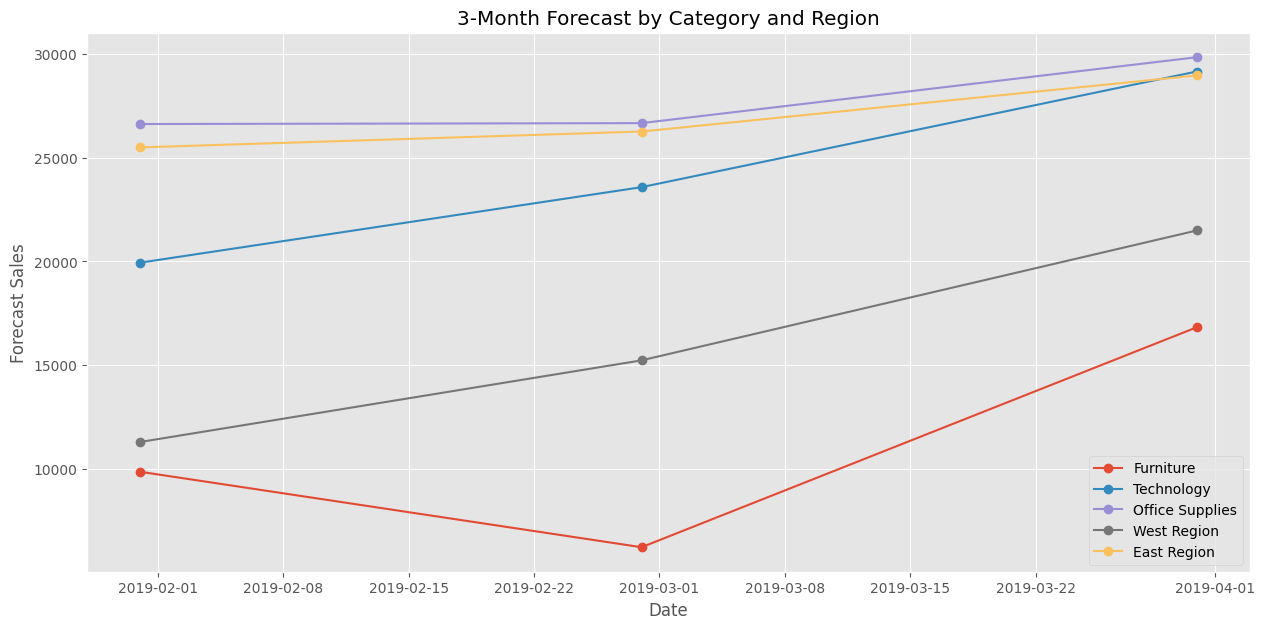

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

plt.plot(
    furniture_forecast['Date'],
    furniture_forecast['Forecast'],
    marker='o',
    label='Furniture'
)

plt.plot(
    technology_forecast['Date'],
    technology_forecast['Forecast'],
    marker='o',
    label='Technology'
)

plt.plot(
    office_forecast['Date'],
    office_forecast['Forecast'],
    marker='o',
    label='Office Supplies'
)

plt.plot(
    west_forecast['Date'],
    west_forecast['Forecast'],
    marker='o',
    label='West Region'
)

plt.plot(
    east_forecast['Date'],
    east_forecast['Forecast'],
    marker='o',
    label='East Region'
)

plt.title("3-Month Forecast by Category and Region")

plt.xlabel("Date")

plt.ylabel("Forecast Sales")

plt.grid(True)

plt.legend()

plt.show()

In [124]:
print("Furniture")
display(furniture_forecast)

print("Technology")
display(technology_forecast)

print("Office Supplies")
display(office_forecast)

print("West")
display(west_forecast)

print("East")
display(east_forecast)

Furniture


,Date,Forecast
0,2019-01-31,9876.913086
1,2019-02-28,6243.917480
2,2019-03-31,16831.087891


Technology


,Date,Forecast
0,2019-01-31,19939.888672
1,2019-02-28,23574.523438
2,2019-03-31,29140.949219


Office Supplies


,Date,Forecast
0,2019-01-31,26613.109375
1,2019-02-28,26656.369141
2,2019-03-31,29828.880859


West


,Date,Forecast
0,2019-01-31,11307.339844
1,2019-02-28,15237.838867
2,2019-03-31,21489.277344


East


,Date,Forecast
0,2019-01-31,25488.318359
1,2019-02-28,26252.371094
2,2019-03-31,28952.652344


In [127]:
growth = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Month 3 Forecast":[
        furniture_forecast['Forecast'].iloc[-1],
        technology_forecast['Forecast'].iloc[-1],
        office_forecast['Forecast'].iloc[-1],
        west_forecast['Forecast'].iloc[-1],
        east_forecast['Forecast'].iloc[-1]
    ]

})
growth = growth.sort_values(
    "Month 3 Forecast",
    ascending=False
).reset_index(drop=True)

growth

,Segment,Month 3 Forecast
0,Office Supplies,29828.880859
1,Technology,29140.949219
2,East Region,28952.652344
3,West Region,21489.277344
4,Furniture,16831.087891


Based on the XGBoost forecasts, the Office Supplies category is expected to show the strongest upcoming growth with a predicted Month 3 sales value of 29,828.88. Among the regions, the East Region is projected to have the strongest growth with forecasted sales of 28,952.65, outperforming the West Region.

# **TASK - 5**

In [128]:
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [129]:
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

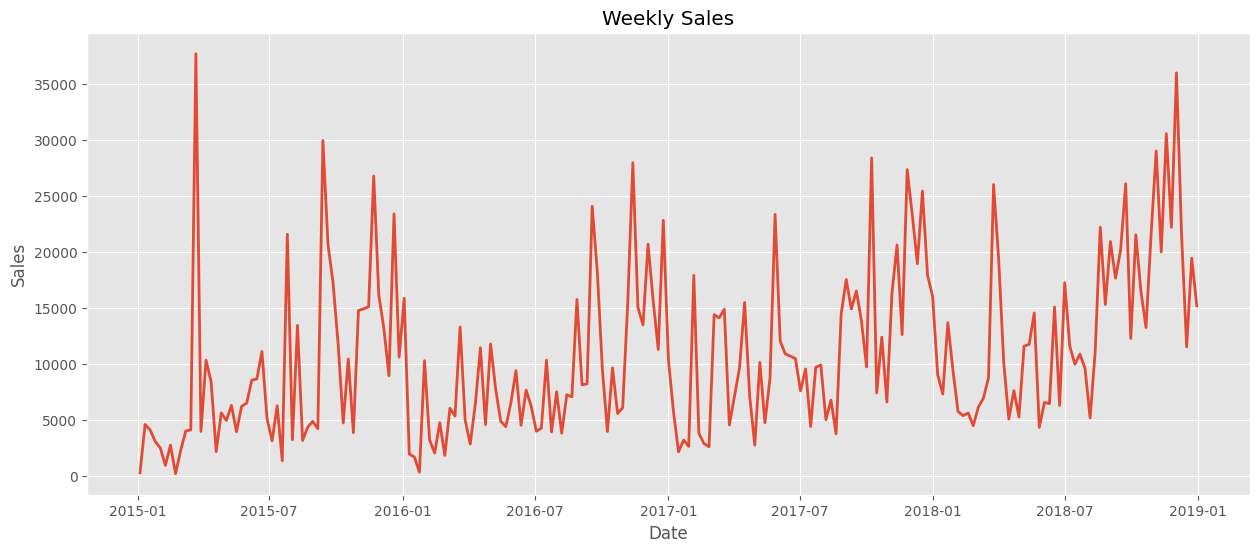

In [130]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    linewidth=2
)

plt.title("Weekly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [131]:
iso = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales['Isolation'] = iso.fit_predict(
    weekly_sales[['Sales']]
)

In [132]:
iso_anomalies = weekly_sales[
    weekly_sales['Isolation']==-1
]

iso_anomalies

,Order Date,Sales,Isolation
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


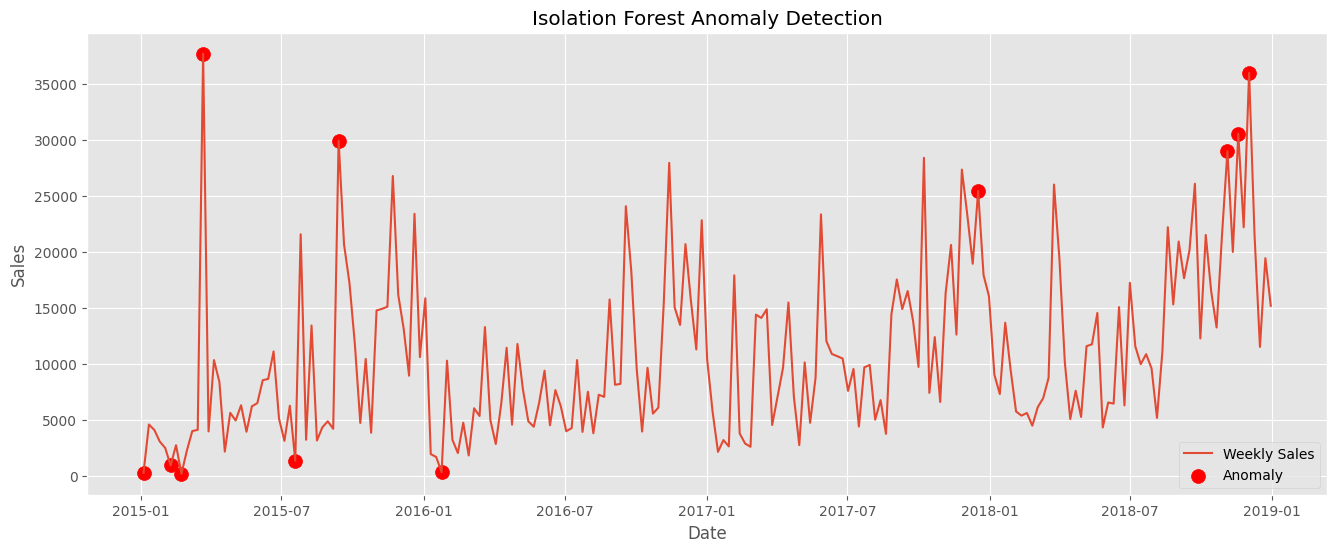

In [133]:
plt.figure(figsize=(16,6))

plt.plot(

    weekly_sales['Order Date'],

    weekly_sales['Sales'],

    label='Weekly Sales'

)

plt.scatter(

    iso_anomalies['Order Date'],

    iso_anomalies['Sales'],

    color='red',

    s=100,

    marker='o',

    label='Anomaly'

)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [134]:
iso_anomalies[['Order Date','Sales']]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


Extremely high sales may correspond to festive shopping seasons such as Black Friday, Christmas, or year-end promotions. Extremely low sales may indicate post-holiday slowdowns, supply chain issues, or reduced customer demand.

In [144]:
mean_sales = weekly_sales['Sales'].mean()

std_sales = weekly_sales['Sales'].std()

In [145]:
weekly_sales['Z Score'] = (
    weekly_sales['Sales'] - mean_sales
) / std_sales

In [146]:
zscore_anomalies = weekly_sales[
    abs(weekly_sales['Z Score']) > 2
]

zscore_anomalies

,Order Date,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Z Anomaly
11,2015-03-22,37703.6650,-1,12040.909500,17129.486138,3.631133,False
36,2015-09-13,29959.1370,-1,10865.594375,12732.296660,2.585063,False
46,2015-11-22,26793.6235,1,17913.440925,5921.728837,2.157490,False
97,2016-11-13,27965.3492,1,13792.468550,10486.257971,2.315758,False
144,2017-10-08,28412.0980,1,17135.491575,8017.339568,2.376101,False
151,2017-11-26,27367.7160,1,19242.780450,6326.563866,2.235034,False
168,2018-03-25,26029.9040,1,11984.656750,9427.179322,2.054333,False
194,2018-09-23,26104.4330,1,21222.323500,3541.697374,2.064400,False
200,2018-11-04,29017.4670,-1,20083.346550,6858.258910,2.457870,False
202,2018-11-18,30572.4470,-1,25285.183500,5282.549382,2.667904,False


In [147]:
zscore_anomalies = weekly_sales[
    abs(weekly_sales['Z Score']) > 2
]

zscore_anomalies

,Order Date,Sales,Isolation,Rolling Mean,Rolling Std,Z Score,Z Anomaly
11,2015-03-22,37703.6650,-1,12040.909500,17129.486138,3.631133,False
36,2015-09-13,29959.1370,-1,10865.594375,12732.296660,2.585063,False
46,2015-11-22,26793.6235,1,17913.440925,5921.728837,2.157490,False
97,2016-11-13,27965.3492,1,13792.468550,10486.257971,2.315758,False
144,2017-10-08,28412.0980,1,17135.491575,8017.339568,2.376101,False
151,2017-11-26,27367.7160,1,19242.780450,6326.563866,2.235034,False
168,2018-03-25,26029.9040,1,11984.656750,9427.179322,2.054333,False
194,2018-09-23,26104.4330,1,21222.323500,3541.697374,2.064400,False
200,2018-11-04,29017.4670,-1,20083.346550,6858.258910,2.457870,False
202,2018-11-18,30572.4470,-1,25285.183500,5282.549382,2.667904,False


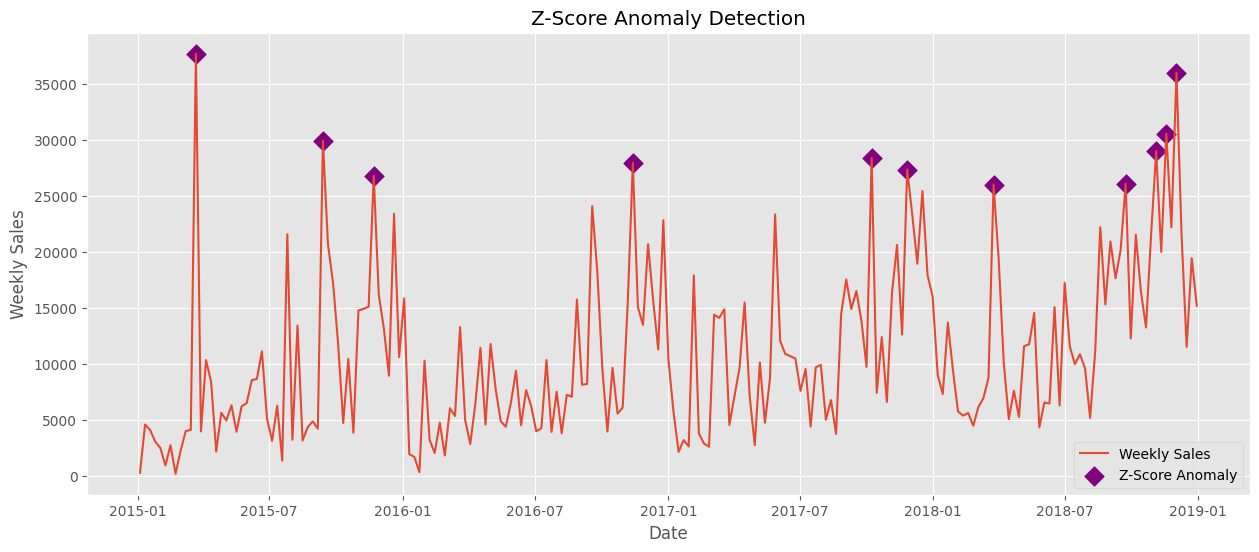

In [148]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Order Date'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    zscore_anomalies['Order Date'],
    zscore_anomalies['Sales'],
    color='purple',
    s=100,
    marker='D',
    label='Z-Score Anomaly'
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.show()

In [149]:
comparison = weekly_sales[['Order Date','Sales']].copy()

comparison['Isolation Forest'] = weekly_sales['Isolation']

comparison['Z Score'] = weekly_sales['Z Anomaly']

comparison.head()

,Order Date,Sales,Isolation Forest,Z Score
0,2015-01-04,304.508,-1,False
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


In [150]:
print("Isolation Forest Anomalies :",

      len(iso_anomalies))

print("Z-Score Anomalies :",

      len(zscore_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 11


In [153]:
common = pd.merge(
    iso_anomalies,
    zscore_anomalies,
    on='Order Date'
)

common[['Order Date']]

,Order Date
0,2015-03-22
1,2015-09-13
2,2018-11-04
3,2018-11-18
4,2018-12-02


In [152]:
print("Common anomalies detected by both methods:")

print(len(common))

Common anomalies detected by both methods:
5


# Real-World Interpretation

The Isolation Forest algorithm detected 11 anomalous weeks, while the Z-Score method also identified 11 anomalous weeks. Among these, 5 weeks were detected by both methods, indicating that these weeks contain strong and statistically significant deviations in sales. These anomalies likely correspond to major promotional campaigns, festive shopping periods, holiday sales, or unexpected changes in customer demand.

# Comparison of Both Methods

Although both methods detected the same number of anomalies, only 5 anomalies overlapped. This difference occurs because the two algorithms use different detection strategies. Isolation Forest is an unsupervised machine learning algorithm that isolates unusual observations based on the overall distribution of the data, allowing it to detect more complex patterns. In contrast, the Z-Score method identifies anomalies purely based on statistical deviation from the mean. As a result, some observations may appear unusual to one method but not the other. Using both techniques together provides a more comprehensive approach to anomaly detection.

Both methods identified 11 anomalies, but only 5 anomalies were common between them. This indicates partial agreement. The common anomalies are highly likely to represent genuine unusual sales events, while the remaining anomalies reflect the different assumptions of each detection method. Isolation Forest captures more complex and nonlinear outliers, whereas the Z-Score method focuses on extreme statistical deviations. Combining both methods improves confidence in identifying meaningful anomalies.

# **TASK - 6**

In [154]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [155]:
monthly_sales = (
    df.groupby(['Sub-Category','Order Date'])['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month

In [156]:
total_sales = (
    monthly_sales.groupby('Sub-Category')['Sales']
    .sum()
)

In [157]:
avg_order = (
    df.groupby('Sub-Category')['Sales']
    .mean()
)

In [158]:
volatility = (
    monthly_sales.groupby('Sub-Category')['Sales']
    .std()
)

In [159]:
yearly_sales = (

    monthly_sales.groupby(

        ['Sub-Category','Year']

    )['Sales']

    .sum()

    .reset_index()

)

In [160]:
growth = (

    yearly_sales

    .groupby('Sub-Category')['Sales']

    .pct_change()

)

In [161]:
yearly_sales['Growth'] = growth

In [162]:
growth_rate = (

    yearly_sales.groupby('Sub-Category')['Growth']

    .mean()

)

In [163]:
cluster_df = pd.DataFrame({

    'Total Sales':total_sales,

    'Growth Rate':growth_rate,

    'Volatility':volatility,

    'Average Order Value':avg_order

})

In [165]:
cluster_df = cluster_df.fillna(0)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,470.693851,217.178175
Appliances,104618.4030,0.399276,431.863487,227.926804
Art,26705.4100,0.166056,81.206390,34.019631
Binders,200028.7850,0.218736,795.599086,134.067550
Bookcases,113813.1987,0.238065,870.654398,503.598224
Chairs,322822.7310,0.071358,798.691728,531.833165
Copiers,146248.0940,0.846718,3232.366779,2215.880212
Envelopes,16128.0460,-0.027666,91.149177,65.032444
Fasteners,3001.9600,0.157034,13.726120,14.027850


In [166]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

In [167]:
#elbow method
wcss = []

for k in range(1,10):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

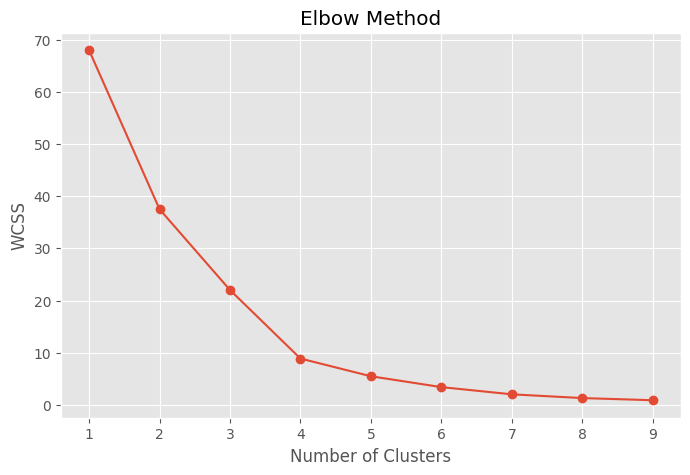

In [168]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,10),

    wcss,

    marker='o'

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [169]:
k = 4

In [170]:
kmeans = KMeans(

    n_clusters=k,

    random_state=42,

    n_init=10

)

cluster_df['Cluster'] = kmeans.fit_predict(
    scaled_data
)

In [213]:
pca = PCA(
    n_components=2
)

principal = pca.fit_transform(
    scaled_data
)
plot_df = pd.DataFrame({

    'PC1':principal[:,0],

    'PC2':principal[:,1],

    'Cluster':cluster_df['Cluster'],

    'Sub-Category':cluster_df.index

})

plot_df.head()

,PC1,PC2,Cluster,Sub-Category
0,-0.334208,-0.147016,2,0
1,-0.539654,0.268431,1,1
2,-1.356274,0.314172,1,2
3,-0.136554,-0.624687,2,3
4,0.048882,-0.019848,2,4


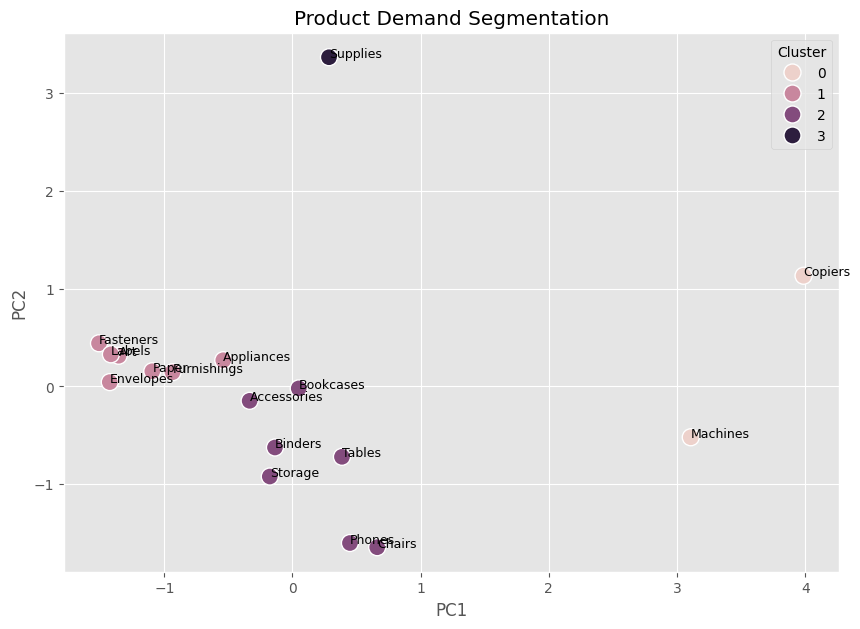

In [173]:
plt.figure(figsize=(10,7))

sns.scatterplot(

    data=plot_df,

    x='PC1',

    y='PC2',

    hue='Cluster',

    s=150

)

for i in range(len(plot_df)):

    plt.text(

        plot_df.iloc[i]['PC1'],

        plot_df.iloc[i]['PC2'],

        plot_df.iloc[i]['Sub-Category'],

        fontsize=9

    )

plt.title("Product Demand Segmentation")

plt.grid(True)

plt.show()

In [174]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,470.693851,217.178175,2
Appliances,104618.4030,0.399276,431.863487,227.926804,1
Art,26705.4100,0.166056,81.206390,34.019631,1
Binders,200028.7850,0.218736,795.599086,134.067550,2
Bookcases,113813.1987,0.238065,870.654398,503.598224,2
Chairs,322822.7310,0.071358,798.691728,531.833165,2
Copiers,146248.0940,0.846718,3232.366779,2215.880212,0
Envelopes,16128.0460,-0.027666,91.149177,65.032444,1
Fasteners,3001.9600,0.157034,13.726120,14.027850,1


In [175]:
cluster_summary = (

    cluster_df

    .groupby('Cluster')

    .mean()

)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value
Cluster,,,,
0,167743.362500,0.463389,3169.223039,1930.716763
1,46977.409571,0.194092,150.184979,75.548331
2,221541.126100,0.189122,695.754129,381.483656
3,46420.308000,1.928448,989.646701,252.284283


In [179]:
cluster_labels = {

    0: "High Value Products",

    1: "Stable & Growing Demand",

    2: "High Volume, High Volatility",

    3: "Rapidly Growing Niche Products"

}

In [180]:
cluster_df['Demand Segment'] = (

    cluster_df['Cluster']

    .map(cluster_labels)

)

In [181]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,Demand Segment
Sub-Category,,,,,,
Accessories,164186.7000,0.376381,470.693851,217.178175,2,"High Volume, High Volatility"
Appliances,104618.4030,0.399276,431.863487,227.926804,1,Stable & Growing Demand
Art,26705.4100,0.166056,81.206390,34.019631,1,Stable & Growing Demand
Binders,200028.7850,0.218736,795.599086,134.067550,2,"High Volume, High Volatility"
Bookcases,113813.1987,0.238065,870.654398,503.598224,2,"High Volume, High Volatility"
Chairs,322822.7310,0.071358,798.691728,531.833165,2,"High Volume, High Volatility"
Copiers,146248.0940,0.846718,3232.366779,2215.880212,0,High Value Products
Envelopes,16128.0460,-0.027666,91.149177,65.032444,1,Stable & Growing Demand
Fasteners,3001.9600,0.157034,13.726120,14.027850,1,Stable & Growing Demand


# **Stocking Strategy**

# High Value Products

Maintain adequate inventory levels with careful demand planning. Since these products have high unit prices, excess inventory should be avoided while ensuring availability during peak demand.

# Stable & Growing Demand

Maintain consistent inventory with regular replenishment. These products exhibit stable demand and gradual growth, making them suitable for routine stock management.

# High Volume, High Volatility

Keep higher safety stock and continuously monitor demand fluctuations. These products contribute significantly to revenue but experience substantial variation in sales.

# Rapidly Growing Niche Products

Closely monitor demand and gradually increase inventory levels. These products show exceptional growth and may become important contributors in the future.

# **TASK - 7**

In [192]:
import joblib

joblib.dump(model_xgb, "xgboost_model.pkl")

print("XGBoost model saved.")

XGBoost model saved.


In [193]:
joblib.dump(kmeans, "kmeans_model.pkl")

print("KMeans model saved.")

KMeans model saved.


In [194]:
df.to_csv("train.csv", index=False)

weekly_sales.to_csv("weekly_sales.csv", index=False)

monthly_sales.reset_index().to_csv("monthly_sales.csv", index=False)

cluster_df.reset_index().to_csv("cluster_data.csv", index=False)

print("All CSV files saved.")

All CSV files saved.


In [202]:
iso_anomalies.to_csv("iso_anomalies.csv", index=False)

zscore_anomalies.to_csv("zscore_anomalies.csv", index=False)

In [214]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------------------------------
# PAGE CONFIGURATION
# ----------------------------------------------------
st.set_page_config(
    page_title="Retail Demand Forecasting Dashboard",
    page_icon="📊",
    layout="wide"
)

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
@st.cache_data
def load_data():

    df = pd.read_csv("train.csv")
    weekly_sales = pd.read_csv("weekly_sales.csv")
    monthly_sales = pd.read_csv("monthly_sales.csv")
    cluster_df = pd.read_csv("cluster_data.csv")

    df["Order Date"] = pd.to_datetime(df["Order Date"])
    weekly_sales["Order Date"] = pd.to_datetime(weekly_sales["Order Date"])
    monthly_sales["Order Date"] = pd.to_datetime(monthly_sales["Order Date"])
    iso_anomalies = pd.read_csv("iso_anomalies.csv")
    zscore_anomalies = pd.read_csv("zscore_anomalies.csv")

    iso_anomalies["Order Date"] = pd.to_datetime(iso_anomalies["Order Date"])
    zscore_anomalies["Order Date"] = pd.to_datetime(zscore_anomalies["Order Date"])

    return (
    df,
    weekly_sales,
    monthly_sales,
    cluster_df,
    iso_anomalies,
    zscore_anomalies
)


(
    df,
    weekly_sales,
    monthly_sales,
    cluster_df,
    iso_anomalies,
    zscore_anomalies
) = load_data()
# ----------------------------------------------------
# LOAD MODELS
# ----------------------------------------------------
model_xgb = joblib.load("xgboost_model.pkl")
kmeans = joblib.load("kmeans_model.pkl")

# ----------------------------------------------------
# SIDEBAR
# ----------------------------------------------------
st.sidebar.title("📊 Retail Demand Forecasting")

page = st.sidebar.radio(
    "Navigation",
    [
        "Sales Overview",
        "Forecast Explorer",
        "Anomaly Report",
        "Demand Segments"
    ]
)

# ==========================================================
# PAGE 1 : SALES OVERVIEW DASHBOARD
# ==========================================================

if page == "Sales Overview":

    st.title("📊 Sales Overview Dashboard")
    st.write("Interactive dashboard for exploring retail sales trends.")

    st.divider()

    # -----------------------------
    # KPI CARDS
    # -----------------------------

    total_sales = df["Sales"].sum()
    total_orders = len(df)
    total_customers = df["Customer ID"].nunique()
    avg_order = df["Sales"].mean()

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "💰 Total Sales",
        f"${total_sales:,.0f}"
    )

    c2.metric(
        "🛒 Orders",
        f"{total_orders:,}"
    )

    c3.metric(
        "👥 Customers",
        f"{total_customers:,}"
    )

    c4.metric(
        "📦 Avg Order Value",
        f"${avg_order:.2f}"
    )

    st.divider()

    # -----------------------------
    # TOTAL SALES BY YEAR
    # -----------------------------

    yearly_sales = (
        df.groupby(df["Order Date"].dt.year)["Sales"]
        .sum()
        .reset_index()
    )

    yearly_sales.columns = ["Year", "Sales"]

    st.subheader("📈 Total Sales by Year")

    fig1 = px.bar(
        yearly_sales,
        x="Year",
        y="Sales",
        color="Sales",
        text_auto=".2s",
        color_continuous_scale="Blues"
    )

    fig1.update_layout(
        height=500,
        xaxis_title="Year",
        yaxis_title="Sales"
    )

    st.plotly_chart(
        fig1,
        width="stretch"
    )

    st.divider()

    # -----------------------------
    # MONTHLY SALES TREND
    # -----------------------------

    st.subheader("📅 Monthly Sales Trend")

    fig2 = px.line(
        monthly_sales,
        x="Order Date",
        y="Sales",
        markers=True
    )

    fig2.update_traces(line=dict(width=3))

    fig2.update_layout(
        height=500,
        xaxis_title="Date",
        yaxis_title="Sales"
    )

    st.plotly_chart(
        fig2,
        width="stretch"
    )

    st.divider()

    # -----------------------------
    # REGION & CATEGORY FILTER
    # -----------------------------

    st.subheader("🌍 Sales by Region & Category")

    col1, col2 = st.columns(2)

    region = col1.selectbox(
        "Select Region",
        sorted(df["Region"].unique())
    )

    category = col2.selectbox(
        "Select Category",
        sorted(df["Category"].unique())
    )

    filtered_df = df[
        (df["Region"] == region) &
        (df["Category"] == category)
    ]

    monthly_filtered = (
        filtered_df
        .groupby(filtered_df["Order Date"].dt.to_period("M"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly_filtered["Order Date"] = monthly_filtered["Order Date"].astype(str)

    fig3 = px.bar(
        monthly_filtered,
        x="Order Date",
        y="Sales",
        color="Sales",
        color_continuous_scale="Viridis"
    )

    fig3.update_layout(
        height=500,
        xaxis_title="Month",
        yaxis_title="Sales"
    )

    st.plotly_chart(
        fig3,
        width="stretch"
    )

    st.success(
        f"Showing {len(filtered_df)} records for **{region}** region and **{category}** category."
    )

    st.subheader("📋 Filtered Dataset")

    st.dataframe(
        filtered_df,
        width="stretch"
    )
# ==========================================================
# PAGE 2 : FORECAST EXPLORER
# ==========================================================

elif page == "Forecast Explorer":

    st.title("📈 Forecast Explorer")
    st.write("Generate demand forecasts using the trained XGBoost model.")

    st.divider()

    forecast_type = st.selectbox(
        "Forecast By",
        ["Category", "Region"]
    )

    if forecast_type == "Category":

        selected = st.selectbox(
            "Select Category",
            sorted(df["Category"].unique())
        )

        data = df[df["Category"] == selected]

    else:

        selected = st.selectbox(
            "Select Region",
            sorted(df["Region"].unique())
        )

        data = df[df["Region"] == selected]

    horizon = st.slider(
        "Forecast Horizon (Months)",
        min_value=1,
        max_value=3,
        value=3
    )

    # ----------------------------------------
    # Monthly Aggregation
    # ----------------------------------------

    monthly = (
        data.groupby("Order Date")["Sales"]
        .sum()
        .resample("M")
        .sum()
        .reset_index()
    )

    monthly.columns = ["Date", "Sales"]

    # ----------------------------------------
    # Feature Engineering
    # ----------------------------------------

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    monthly["Month"] = monthly["Date"].dt.month
    monthly["Quarter"] = monthly["Date"].dt.quarter

    def get_season(month):

        if month in [12,1,2]:
            return 1

        elif month in [3,4,5]:
            return 2

        elif month in [6,7,8]:
            return 3

        else:
            return 4

    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly = monthly.dropna().reset_index(drop=True)

    # ----------------------------------------
    # Recursive Forecast
    # ----------------------------------------

    history = monthly.copy()

    predictions = []

    future_dates = []

    last_date = history["Date"].iloc[-1]

    for i in range(horizon):

        lag1 = history["Sales"].iloc[-1]
        lag2 = history["Sales"].iloc[-2]
        lag3 = history["Sales"].iloc[-3]

        rolling = history["Sales"].iloc[-3:].mean()

        next_date = last_date + pd.DateOffset(months=1)

        month = next_date.month
        quarter = next_date.quarter
        season = get_season(month)

        X = pd.DataFrame({

            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean_3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]

        })

        pred = model_xgb.predict(X)[0]

        predictions.append(pred)

        future_dates.append(next_date)

        history.loc[len(history)] = [

            next_date,
            pred,
            lag1,
            lag2,
            lag3,
            rolling,
            month,
            quarter,
            season

        ]

        last_date = next_date

    forecast_df = pd.DataFrame({

        "Forecast Date":future_dates,
        "Forecast Sales":predictions

    })

    st.divider()

    # ----------------------------------------
    # Forecast Chart
    # ----------------------------------------

    st.subheader("📈 Forecast Results")

    fig = go.Figure()

    # Historical Sales
    fig.add_trace(
        go.Scatter(
            x=monthly["Date"],
            y=monthly["Sales"],
            mode="lines+markers",
            name="Historical Sales"
        )
    )

    # Forecast Sales
    fig.add_trace(
        go.Scatter(
            x=forecast_df["Forecast Date"],
            y=forecast_df["Forecast Sales"],
            mode="lines+markers",
            name="Forecast",
            line=dict(color="red", width=3)
        )
    )

    fig.update_layout(

        title=f"Sales Forecast for {selected}",

        xaxis_title="Date",

        yaxis_title="Sales",

        template="plotly_white",

        height=550

    )

    st.plotly_chart(
        fig,
        width="stretch"
    )

    st.divider()

    # ----------------------------------------
    # Forecast Table
    # ----------------------------------------

    st.subheader("📋 Forecast Values")

    forecast_display = forecast_df.copy()

    forecast_display["Forecast Date"] = (
        forecast_display["Forecast Date"]
        .dt.strftime("%b %Y")
    )

    forecast_display["Forecast Sales"] = (
        forecast_display["Forecast Sales"]
        .round(2)
    )

    st.dataframe(
        forecast_display,
        width="stretch"
    )

    st.divider()

    # ----------------------------------------
    # Model Performance
    # ----------------------------------------

    st.subheader("📊 Model Performance")

    # Values obtained from Task 3
    mae = 14763.81
    rmse = 18337.41
    mape = 14.48

    c1, c2, c3 = st.columns(3)

    c1.metric(
        "MAE",
        f"{mae:,.2f}"
    )

    c2.metric(
        "RMSE",
        f"{rmse:,.2f}"
    )

    c3.metric(
        "MAPE",
        f"{mape:.2f}%"
    )

    st.info(
        """
        **Best Model:** XGBoost

        This model was selected because it achieved the lowest MAE,
        RMSE and MAPE among SARIMA, Prophet and XGBoost during
        model evaluation.
        """
    )
# ==========================================================
# PAGE 3 : ANOMALY REPORT
# ==========================================================

elif page == "Anomaly Report":

    st.title("🚨 Sales Anomaly Report")
    st.write("Identify unusual sales patterns detected using Isolation Forest and Z-Score.")

    st.divider()

    # -----------------------------
    # Weekly Sales Chart
    # -----------------------------

    st.subheader("Weekly Sales with Detected Anomalies")

    fig = go.Figure()

    # Weekly Sales
    fig.add_trace(
        go.Scatter(
            x=weekly_sales["Order Date"],
            y=weekly_sales["Sales"],
            mode="lines",
            name="Weekly Sales",
            line=dict(width=2)
        )
    )

    # Isolation Forest Anomalies
    fig.add_trace(
        go.Scatter(
            x=iso_anomalies["Order Date"],
            y=iso_anomalies["Sales"],
            mode="markers",
            name="Isolation Forest",
            marker=dict(
                color="red",
                size=10,
                symbol="circle"
            )
        )
    )

    # Z-Score Anomalies
    fig.add_trace(
        go.Scatter(
            x=zscore_anomalies["Order Date"],
            y=zscore_anomalies["Sales"],
            mode="markers",
            name="Z-Score",
            marker=dict(
                color="blue",
                size=10,
                symbol="diamond"
            )
        )
    )

    fig.update_layout(

        title="Weekly Sales Anomaly Detection",

        xaxis_title="Date",

        yaxis_title="Sales",

        template="plotly_white",

        height=550

    )

    st.plotly_chart(
        fig,
        width="stretch"
    )

    st.divider()

    # -----------------------------
    # Isolation Forest Table
    # -----------------------------

    st.subheader("Isolation Forest Anomalies")

    iso_display = iso_anomalies[["Order Date", "Sales"]].copy()

    iso_display["Order Date"] = (
        pd.to_datetime(iso_display["Order Date"])
        .dt.strftime("%d-%b-%Y")
    )

    iso_display["Sales"] = iso_display["Sales"].round(2)

    st.dataframe(
        iso_display,
        width="stretch"
    )

    st.divider()

    # -----------------------------
    # Z Score Table
    # -----------------------------

    st.subheader("Z-Score Anomalies")

    z_display = zscore_anomalies[["Order Date", "Sales"]].copy()

    z_display["Order Date"] = (
        pd.to_datetime(z_display["Order Date"])
        .dt.strftime("%d-%b-%Y")
    )

    z_display["Sales"] = z_display["Sales"].round(2)

    st.dataframe(
        z_display,
        width="stretch"
    )

    st.divider()

    # -----------------------------
    # KPI Cards
    # -----------------------------

    c1, c2, c3 = st.columns(3)

    c1.metric(
        "Isolation Forest",
        len(iso_anomalies)
    )

    c2.metric(
        "Z-Score",
        len(zscore_anomalies)
    )

    common = pd.merge(
        iso_anomalies,
        zscore_anomalies,
        on="Order Date"
    )

    c3.metric(
        "Common Anomalies",
        len(common)
    )

    st.info(
        """
        Isolation Forest identifies anomalies using an unsupervised
        machine learning approach, while Z-Score flags observations
        that deviate significantly from the statistical mean.
        Common anomalies detected by both methods are considered
        the strongest indicators of unusual sales behavior.
        """
    )
    # ==========================================================
# PAGE 4 : PRODUCT DEMAND SEGMENTS
# ==========================================================

elif page == "Demand Segments":

    st.title("📦 Product Demand Segments")
    st.write("Visualize product clusters and their demand characteristics.")

    st.divider()

    # -----------------------------
    # Cluster Scatter Plot
    # -----------------------------

    st.subheader("Demand Segmentation using K-Means Clustering")
    # -----------------------------
    # Generate PCA Coordinates
    # -----------------------------

    features = cluster_df[[
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order Value"
    ]]

    scaler = StandardScaler()

    scaled_features = scaler.fit_transform(features)

    pca = PCA(n_components=2)

    pca_result = pca.fit_transform(scaled_features)

    cluster_df["PC1"] = pca_result[:, 0]
    cluster_df["PC2"] = pca_result[:, 1]

    fig = px.scatter(

        cluster_df,

        x="PC1",

        y="PC2",

        color="Demand Segment",

        hover_name="Sub-Category",

        size="Total Sales",

        title="Product Demand Clusters"

    )

    fig.update_layout(

        template="plotly_white",

        height=600

    )

    st.plotly_chart(

        fig,

        width="stretch"

    )

    st.divider()

    # -----------------------------
    # Cluster Table
    # -----------------------------

    st.subheader("Product Demand Segments")

    display_df = cluster_df[[

        "Sub-Category",

        "Demand Segment",

        "Cluster",

        "Total Sales",

        "Growth Rate",

        "Volatility",

        "Average Order Value"

    ]]

    st.dataframe(

        display_df,

        width="stretch"

    )

    st.divider()

    # -----------------------------
    # Cluster Summary
    # -----------------------------

    st.subheader("Products in Each Demand Segment")

    summary = (

        cluster_df

        .groupby("Demand Segment")["Sub-Category"]

        .apply(list)

        .reset_index()

    )

    for i in range(len(summary)):

        st.markdown(f"### {summary.iloc[i]['Demand Segment']}")

        st.write(", ".join(summary.iloc[i]["Sub-Category"]))

    st.divider()

    # -----------------------------
    # Stocking Strategy
    # -----------------------------

    st.subheader("Recommended Stocking Strategy")

    st.success("""

✅ **High Value Products**

Maintain adequate inventory while avoiding excess stock due to high unit cost.

---

✅ **Stable & Growing Demand**

Keep regular inventory with scheduled replenishment to meet consistent customer demand.

---

✅ **High Volume, High Volatility**

Maintain higher safety stock and monitor demand frequently to avoid stockouts.

---

✅ **Rapidly Growing Niche Products**

Increase inventory gradually and closely monitor future demand trends before scaling further.

    """)

Overwriting app.py


In [215]:
!pip install -q streamlit plotly joblib xgboost scikit-learn

In [219]:
!pkill -f streamlit

In [223]:
!streamlit run app.py > /content/log.txt 2>&1 &

In [227]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
joblib
xgboost
scikit-learn

Writing requirements.txt


In [228]:
import os

files = [
    "app.py",
    "requirements.txt",
    "train.csv",
    "weekly_sales.csv",
    "monthly_sales.csv",
    "cluster_data.csv",
    "iso_anomalies.csv",
    "zscore_anomalies.csv",
    "xgboost_model.pkl",
    "kmeans_model.pkl"
]

for f in files:
    print(f, "✅" if os.path.exists(f) else "❌ Missing")

app.py ✅
requirements.txt ✅
train.csv ✅
weekly_sales.csv ✅
monthly_sales.csv ✅
cluster_data.csv ✅
iso_anomalies.csv ✅
zscore_anomalies.csv ✅
xgboost_model.pkl ✅
kmeans_model.pkl ✅


In [230]:
from google.colab import files

files.download("Retail_Demand_Forecasting.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [231]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")
files.download("train.csv")
files.download("weekly_sales.csv")
files.download("monthly_sales.csv")
files.download("cluster_data.csv")
files.download("iso_anomalies.csv")
files.download("zscore_anomalies.csv")
files.download("xgboost_model.pkl")
files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 📊 Business Insights

Based on the analysis and forecasting results, the following key business insights were obtained:

- Office Supplies and Technology are expected to generate the highest sales over the next three months.
- Sales exhibit clear seasonal patterns, with increased demand during festive and year-end shopping periods.
- The East region is projected to outperform the West region in terms of future sales.
- XGBoost delivered the best forecasting performance (MAE: 14,763.81, RMSE: 18,337.41, MAPE: 14.48%) and was selected as the production model.
- Anomaly detection successfully identified unusual sales spikes corresponding to promotional and festive periods.
- Product demand segmentation enables differentiated inventory strategies, helping reduce overstocking and stockout risks.

# Conclusion

This project successfully developed an end-to-end Retail Demand Forecasting and Inventory Intelligence System by integrating exploratory data analysis, time series forecasting, anomaly detection, product demand segmentation, and an interactive Streamlit dashboard.

Among the evaluated forecasting models, XGBoost achieved the highest accuracy and was selected as the final forecasting model. The developed solution provides actionable insights that can support inventory planning, improve demand forecasting, optimize stock levels, and enable data-driven decision-making for retail businesses. The deployed Streamlit dashboard further allows business users to interactively explore sales trends, forecasts, anomalies, and demand segments without requiring technical expertise.